<a href="https://colab.research.google.com/github/bahareh-ghaffari/walmart-weekly-sales-prediction/blob/main/walmart_weekly_sales_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Walmart Weekly Sales Prediction

## Executive summary

This project builds and compares machine-learning models for predicting store-level weekly sales across 45 Walmart stores. The analysis combines exploratory data analysis, calendar feature engineering, chronological validation, hyperparameter tuning, and model comparison.

**Best model:** Tuned Decision Tree  
**Test MAE:** \$72,798  
**Test RMSE:** \$102,746  
**Test R²:** 0.963

The selected model reduced MAE by approximately 21.5% compared with Linear Regression. The results can support inventory planning, staffing, budgeting, and promotion decisions.

### Questions addressed

- How do sales vary across stores and throughout the year?
- Are high-sales observations errors or meaningful seasonal events?
- Do holiday weeks have higher average sales?
- Which regression model generalizes best to a future holdout period?
- How much does tuning reduce overfitting?

### Workflow

1. Data loading and quality checks
2. Exploratory data analysis
3. Feature engineering
4. Chronological train/test split
5. Model training and time-series cross-validation
6. Model comparison and business interpretation


In [1]:
import pandas as pd

In [2]:
import kagglehub

dataset_path = kagglehub.dataset_download("yasserh/walmart-dataset")

print(dataset_path)

100%|██████████| 122k/122k [00:00<00:00, 58.9MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/yasserh/walmart-dataset/versions/1


In [3]:
file_path = dataset_path + "/Walmart.csv"

print(file_path)


/root/.cache/kagglehub/datasets/yasserh/walmart-dataset/versions/1/Walmart.csv


In [4]:
df = pd.read_csv(file_path)

In [5]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## 1. Data Understanding and Quality Checks

Before cleaning or modeling, we examine the dataset's size, columns, data types, missing values, duplicates, and basic statistics.


In [6]:

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 6435
Number of columns: 8


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [8]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Date"].dtype

dtype('O')

In [11]:
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y"
)

In [12]:
df["Date"].dtype

dtype('<M8[ns]')

In [13]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [14]:
print("First date:", df["Date"].min())
print("Last date:", df["Date"].max())

First date: 2010-02-05 00:00:00
Last date: 2012-10-26 00:00:00


### Descriptive Statistics

Descriptive statistics help us understand the typical values, ranges, and possible unusual values in the numerical variables.


In [15]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885


In [16]:
df.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
Store,6435.0,23.0,1.0,12.0,23.0,34.0,45.0,12.988182
Date,6435,2011-06-17 00:00:00,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00,NaN
Weekly_Sales,6435.0,1046964.877562,209986.25,553350.105,960746.04,1420158.66,3818686.45,564366.622054
Holiday_Flag,6435.0,0.06993,0.0,0.0,0.0,0.0,1.0,0.255049
Temperature,6435.0,60.663782,-2.06,47.46,62.67,74.94,100.14,18.444933
Fuel_Price,6435.0,3.358607,2.472,2.933,3.445,3.735,4.468,0.45902
CPI,6435.0,171.578394,126.064,131.735,182.616521,212.743293,227.232807,39.356712
Unemployment,6435.0,7.999151,3.879,6.891,7.874,8.622,14.313,1.875885


In [17]:
df["Weekly_Sales"].describe().apply(
    lambda value: f"${value:,.2f}"
)

,Weekly_Sales
count,"$6,435.00"
mean,"$1,046,964.88"
std,"$564,366.62"
min,"$209,986.25"
25%,"$553,350.10"
50%,"$960,746.04"
75%,"$1,420,158.66"
max,"$3,818,686.45"


In [18]:
holiday_counts = df["Holiday_Flag"].value_counts()

holiday_counts

,count
Holiday_Flag,
0,5985
1,450


In [19]:
holiday_percentages = (
    df["Holiday_Flag"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

holiday_percentages

,proportion
Holiday_Flag,
0,93.01
1,6.99


In [20]:
df.groupby("Store").size()

,0
Store,
1,143
2,143
3,143
4,143
5,143
6,143
7,143
8,143
9,143


In [21]:
df.groupby("Store").size().describe()

,0
count,45.0
mean,143.0
std,0.0
min,143.0
25%,143.0
50%,143.0
75%,143.0
max,143.0


**Finding:** The dataset contains 45 stores, and every store has exactly 143 weekly observations. Therefore, the dataset is balanced across stores, with no store underrepresented by row count.


## 2. Exploratory Data Analysis

Exploratory Data Analysis helps us identify distributions, patterns, relationships, seasonality, and possible unusual values before building machine-learning models.


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

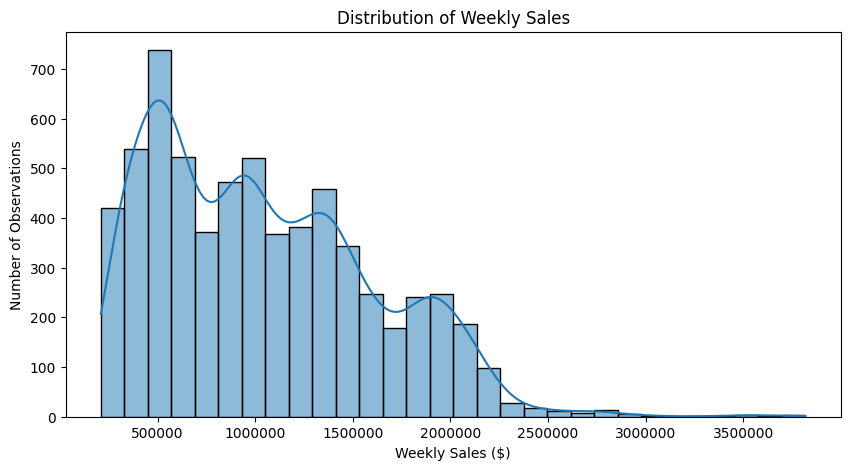

In [23]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Weekly_Sales",
    bins=30,
    kde=True
)

plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales ($)")
plt.ylabel("Number of Observations")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

**Finding:** Weekly sales have a right-skewed and multimodal distribution. Most observations are below $2 million, while a small number of high-sales weeks create a long right tail. These high values should be investigated before being classified as errors or removed because they may represent holiday periods or consistently high-performing stores.


In [24]:
sales_skewness = df["Weekly_Sales"].skew()

print("Weekly sales skewness:", round(sales_skewness, 2))

Weekly sales skewness: 0.67


**Finding:** Weekly sales have a moderate positive skewness of 0.67.


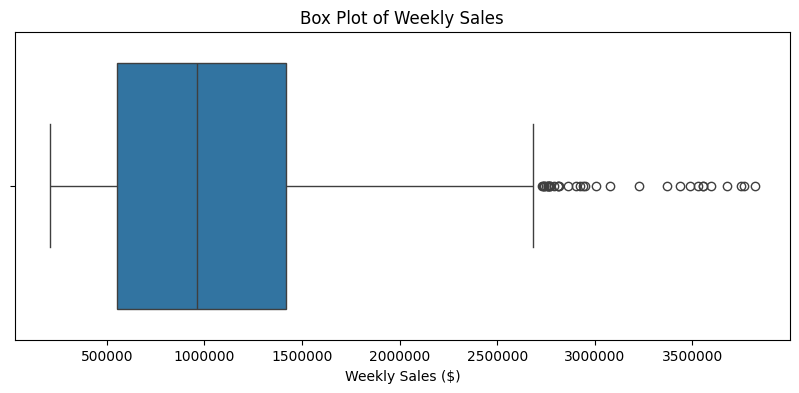

In [25]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x="Weekly_Sales"
)

plt.title("Box Plot of Weekly Sales")
plt.xlabel("Weekly Sales ($)")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

**Finding:** The box plot identifies several potential high-sales outliers. However, these observations should not be removed automatically because they may represent valid holiday periods or consistently high-performing stores.


In [26]:
q1 = df["Weekly_Sales"].quantile(0.25)
q3 = df["Weekly_Sales"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1:", f"${q1:,.2f}")
print("Q3:", f"${q3:,.2f}")
print("IQR:", f"${iqr:,.2f}")
print("Lower boundary:", f"${lower_bound:,.2f}")
print("Upper boundary:", f"${upper_bound:,.2f}")

Q1: $553,350.10
Q3: $1,420,158.66
IQR: $866,808.55
Lower boundary: $-746,862.73
Upper boundary: $2,720,371.49


In [27]:
sales_outliers = df[
    df["Weekly_Sales"] > upper_bound
]

print("Number of potential outliers:", len(sales_outliers))

Number of potential outliers: 34


In [28]:
sales_outliers.sort_values(
    by="Weekly_Sales",
    ascending=False
).head(10)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
1905,14,2010-12-24,3818686.45,0,30.59,3.141,182.544590,8.724
2763,20,2010-12-24,3766687.43,0,25.17,3.141,204.637673,7.484
1333,10,2010-12-24,3749057.69,0,57.06,3.236,126.983581,9.003
527,4,2011-12-23,3676388.98,0,35.92,3.103,129.984548,5.143
1762,13,2010-12-24,3595903.20,0,34.90,2.846,126.983581,7.795
1814,13,2011-12-23,3556766.03,0,24.76,3.186,129.984548,6.392
2815,20,2011-12-23,3555371.03,0,40.19,3.389,212.236040,7.082
475,4,2010-12-24,3526713.39,0,43.21,2.887,126.983581,7.127
1385,10,2011-12-23,3487986.89,0,48.36,3.541,129.984548,7.874
189,2,2010-12-24,3436007.68,0,49.97,2.886,211.064660,8.163


**Outlier decision:** The IQR method identified 34 potential high-sales outliers, representing approximately 0.53% of the dataset. Most of the largest observations occurred during the weeks immediately before Christmas and appeared across several high-performing stores. These values represent meaningful seasonal sales patterns rather than obvious data errors, so they were retained.


In [29]:
holiday_sales = df.groupby("Holiday_Flag")["Weekly_Sales"].agg(
    ["count", "mean", "median"]
)

holiday_sales.round(2)

,count,mean,median
Holiday_Flag,,,
0,5985,1041256.38,956211.20
1,450,1122887.89,1018538.04


In [30]:
regular_mean = holiday_sales.loc[0, "mean"]
holiday_mean = holiday_sales.loc[1, "mean"]

holiday_increase = (
    (holiday_mean - regular_mean) / regular_mean
) * 100

print(
    "Average holiday sales increase:",
    round(holiday_increase, 2),
    "%"
)

Average holiday sales increase: 7.84 %


**Finding:** Designated holiday weeks had average sales of approximately $1.12 million, compared with $1.04 million during regular weeks. This represents an average increase of approximately 7.84%. However, this comparison shows an association and does not prove that the holiday flag alone caused the increase.


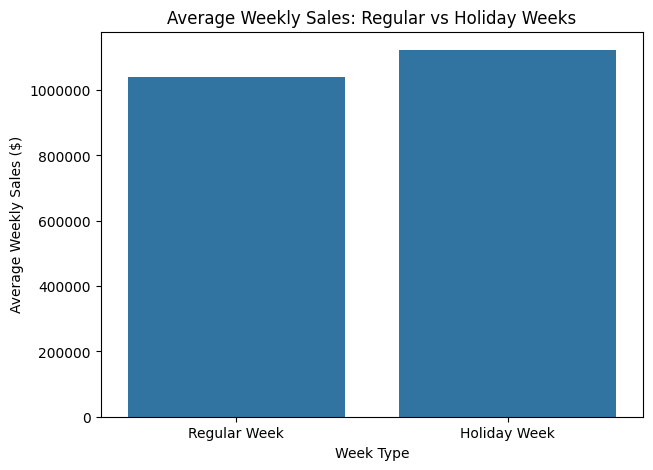

In [31]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="Holiday_Flag",
    y="Weekly_Sales",
    errorbar=None
)

plt.title("Average Weekly Sales: Regular vs Holiday Weeks")
plt.xlabel("Week Type")
plt.ylabel("Average Weekly Sales ($)")
plt.xticks([0, 1], ["Regular Week", "Holiday Week"])
plt.ticklabel_format(style="plain", axis="y")
plt.show()

**Finding:** Average weekly sales were higher during designated holiday weeks than during regular weeks. Holiday weeks averaged approximately $1.12 million, compared with $1.04 million for regular weeks—an increase of about 7.84%.


In [32]:
weekly_total_sales = (
    df.groupby("Date", as_index=False)["Weekly_Sales"]
    .sum()
)

In [33]:
weekly_total_sales.head()

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


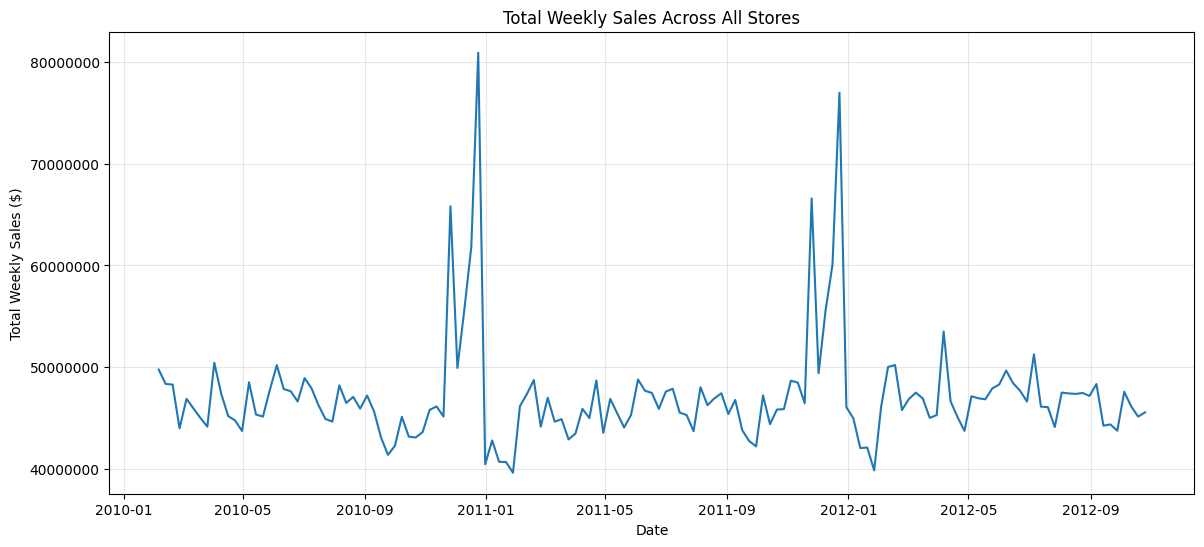

In [34]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=weekly_total_sales,
    x="Date",
    y="Weekly_Sales"
)

plt.title("Total Weekly Sales Across All Stores")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales ($)")
plt.ticklabel_format(style="plain", axis="y")
plt.grid(alpha=0.3)
plt.show()

**Finding:** Total weekly sales usually ranged from approximately $40 million to $50 million. Strong spikes occurred near the end of 2010 and 2011, indicating significant holiday-season effects. No comparable spike appears in 2012 because the dataset ends in October.


In [35]:
top_sales_weeks = weekly_total_sales.nlargest(
    10,
    "Weekly_Sales"
).copy()

top_sales_weeks["Weekly_Sales"] = (
    top_sales_weeks["Weekly_Sales"]
    .round(2)
)

top_sales_weeks

,Date,Weekly_Sales
46,2010-12-24,80931415.60
98,2011-12-23,76998241.31
94,2011-11-25,66593605.26
42,2010-11-26,65821003.24
45,2010-12-17,61820799.85
97,2011-12-16,60085695.94
44,2010-12-10,55666770.39
96,2011-12-09,55561147.70
113,2012-04-06,53502315.87
126,2012-07-06,51253021.88


**Finding:** The highest total-sales weeks were concentrated around Christmas and Thanksgiving. This confirms strong annual seasonality and demonstrates why date-related features are needed in addition to the existing holiday flag.


## 3. Feature Engineering

Calendar features are extracted from the date so the models can learn annual trends and seasonal patterns. `Month` is retained for exploratory summaries, while `Week_of_Year` is used for modeling because the two variables contain similar calendar information.


In [36]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week_of_Year"] = df["Date"].dt.isocalendar().week.astype(int)

In [37]:
df[
    ["Date", "Year", "Month", "Week_of_Year"]
].head()

,Date,Year,Month,Week_of_Year
0,2010-02-05,2010,2,5
1,2010-02-12,2010,2,6
2,2010-02-19,2010,2,7
3,2010-02-26,2010,2,8
4,2010-03-05,2010,3,9


In [38]:
df.shape

(6435, 11)

In [39]:
monthly_sales = (
    df.groupby("Month", as_index=False)["Weekly_Sales"]
    .mean()
)

monthly_sales

,Month,Weekly_Sales
0,1,9.238846e+05
1,2,1.053200e+06
2,3,1.013309e+06
3,4,1.026762e+06
4,5,1.031714e+06
5,6,1.064325e+06
6,7,1.031748e+06
7,8,1.048017e+06
8,9,9.893353e+05
9,10,9.996321e+05


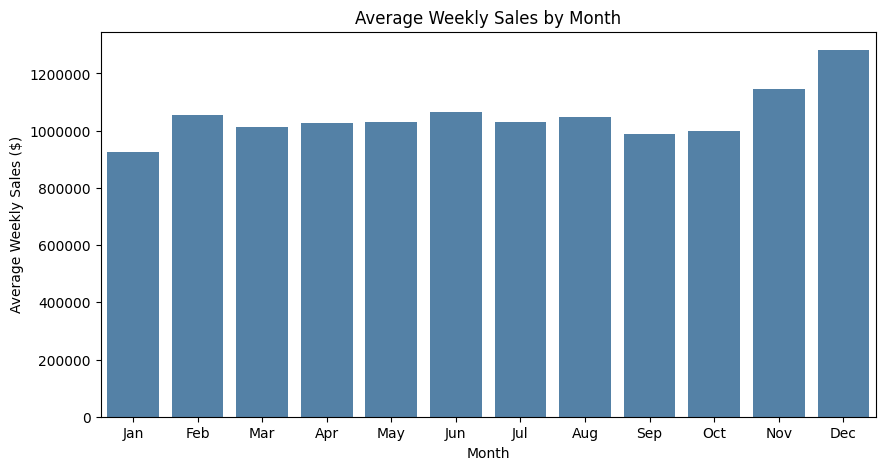

In [40]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=monthly_sales,
    x="Month",
    y="Weekly_Sales",
    color="steelblue"
)

plt.title("Average Weekly Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales ($)")
plt.xticks(
    ticks=range(12),
    labels=[
        "Jan", "Feb", "Mar", "Apr",
        "May", "Jun", "Jul", "Aug",
        "Sep", "Oct", "Nov", "Dec"
    ]
)
plt.ticklabel_format(style="plain", axis="y")
plt.show()

### Correlation Analysis

Correlation measures the direction and strength of a linear relationship between two numerical variables.


In [41]:
correlation_columns = [
    "Weekly_Sales",
    "Holiday_Flag",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Year",
    "Month",
    "Week_of_Year"
]

In [42]:
correlation_matrix = df[correlation_columns].corr()

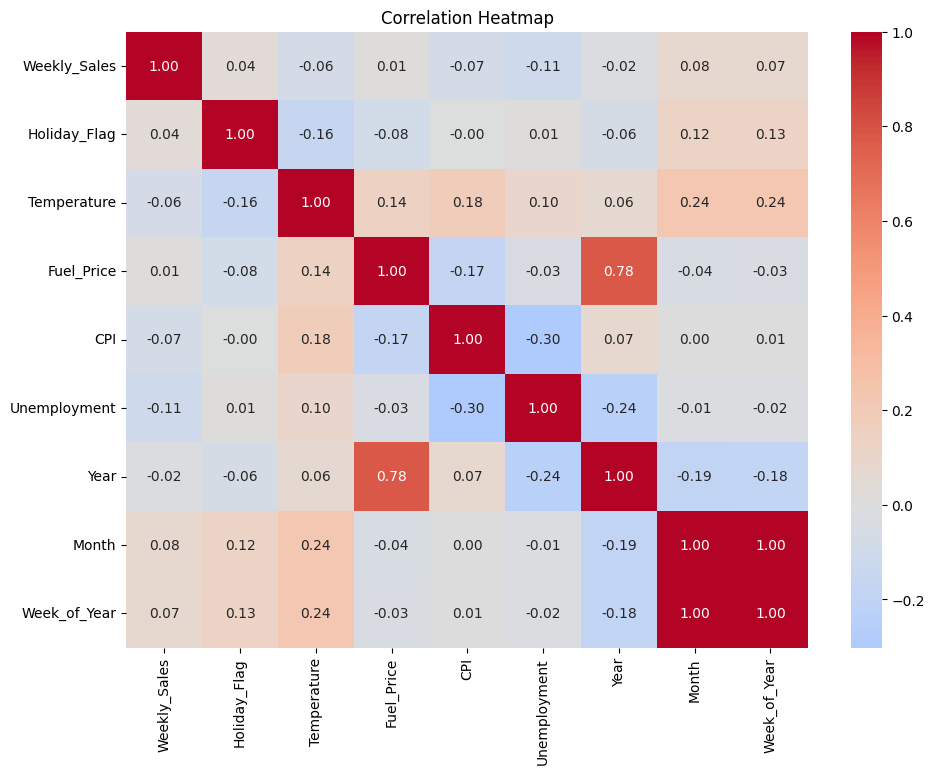

In [43]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

**Finding:** No numerical feature had a strong linear correlation with weekly sales. Unemployment had the strongest relationship at only -0.11. Month and week-of-year were almost perfectly correlated, meaning they contain largely redundant calendar information. These weak target correlations do not mean the features are useless because tree-based models can identify nonlinear relationships and feature interactions.


In [44]:
store_sales = (
    df.groupby("Store", as_index=False)["Weekly_Sales"]
    .mean()
    .sort_values("Weekly_Sales", ascending=False)
)

store_sales.head(10)


,Store,Weekly_Sales
19,20,2.107677e+06
3,4,2.094713e+06
13,14,2.020978e+06
12,13,2.003620e+06
1,2,1.925751e+06
9,10,1.899425e+06
26,27,1.775216e+06
5,6,1.564728e+06
0,1,1.555264e+06
38,39,1.450668e+06


In [45]:
store_sales.head(10).style.format({
    "Weekly_Sales": "${:,.2f}"
})

,Store,Weekly_Sales
19,20,"$2,107,676.87"
3,4,"$2,094,712.96"
13,14,"$2,020,978.40"
12,13,"$2,003,620.31"
1,2,"$1,925,751.34"
9,10,"$1,899,424.57"
26,27,"$1,775,216.20"
5,6,"$1,564,728.19"
0,1,"$1,555,264.40"
38,39,"$1,450,668.13"


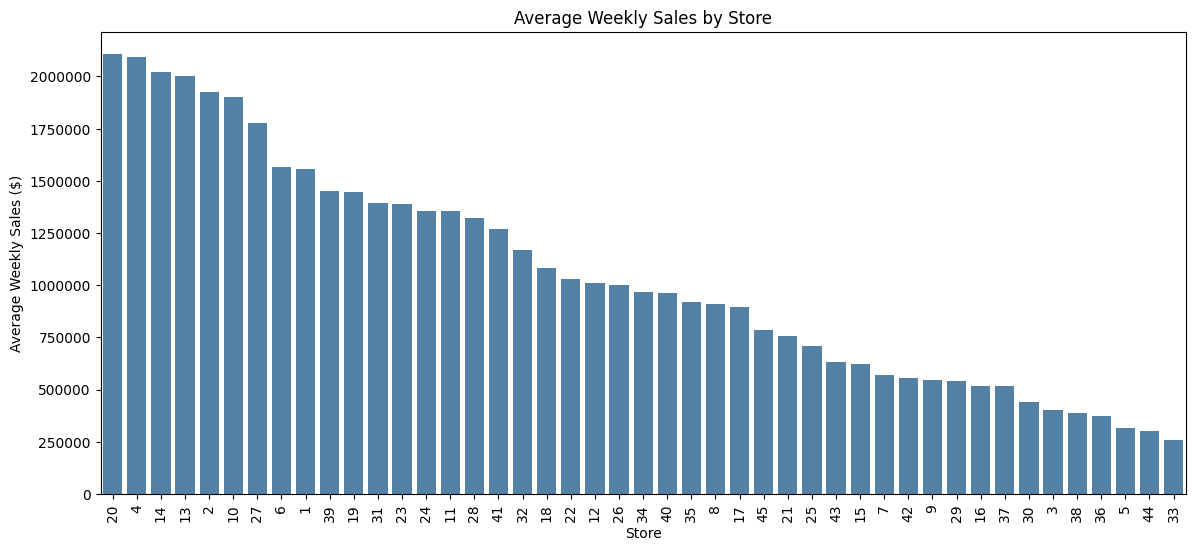

In [46]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=store_sales,
    x="Store",
    y="Weekly_Sales",
    order=store_sales["Store"],
    color="steelblue"
)

plt.title("Average Weekly Sales by Store")
plt.xlabel("Store")
plt.ylabel("Average Weekly Sales ($)")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=90)
plt.show()

**Finding:** Average weekly sales varied substantially between stores. Store 20 averaged approximately $2.11 million, while Store 33 averaged  approximately $260,000. The highest-selling store averaged roughly eight times the sales of the lowest-selling store. Store identity is therefore expected to be an important categorical predictor.


In [47]:
highest_store_sales = store_sales["Weekly_Sales"].max()
lowest_store_sales = store_sales["Weekly_Sales"].min()

store_sales_ratio = highest_store_sales / lowest_store_sales

print(
    "The highest-selling store averages",
    round(store_sales_ratio, 2),
    "times the sales of the lowest-selling store."
)

The highest-selling store averages 8.11 times the sales of the lowest-selling store.


## 4. Model Preparation and Validation Strategy

The target is Weekly_Sales. The features include store identity, economic information, holiday status, and engineered calendar variables.


In [48]:
feature_columns = [
    "Store",
    "Holiday_Flag",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Year",
    "Week_of_Year"
]

In [49]:
X = df[feature_columns]
y = df["Weekly_Sales"]

In [50]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6435, 8)
y shape: (6435,)


In [51]:
unique_dates = sorted(df["Date"].unique())

split_position = int(len(unique_dates) * 0.80)
split_date = unique_dates[split_position]

print("Split date:", split_date)

Split date: 2012-04-13 00:00:00


In [52]:
train_mask = df["Date"] < split_date
test_mask = df["Date"] >= split_date

In [53]:
X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

In [54]:
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("Training ends:", df.loc[train_mask, "Date"].max())
print("Testing begins:", df.loc[test_mask, "Date"].min())

Training rows: 5130
Testing rows: 1305
Training ends: 2012-04-06 00:00:00
Testing begins: 2012-04-13 00:00:00


**Data-splitting decision:** The first 80% of weekly dates were used for training, and the final 20% were reserved for testing. A chronological split prevents future sales information from leaking into model training.


### Evaluation metrics

- **MAE** measures the average absolute prediction error in dollars and is the primary selection metric because it is easy for business users to interpret.
- **RMSE** gives more weight to large forecasting errors.
- **R²** measures the proportion of sales variation explained by the model.

All models are evaluated on the same untouched future test period for a fair comparison.


## 5. Linear Regression

Linear Regression is used as the first baseline machine-learning model. It estimates weekly sales as a weighted combination of the input features.


In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [56]:
categorical_features = ["Store"]

numerical_features = [
    "Holiday_Flag",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Year",
    "Week_of_Year"
]

In [57]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "store_encoder",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "number_scaler",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [58]:
linear_model = Pipeline(
    steps=[
        ("preprocessing", linear_preprocessor),
        ("model", LinearRegression())
    ]
)

In [59]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('store_encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Store']),
                                                 ('number_scaler',
                                                  StandardScaler(),
                                                  ['Holiday_Flag',
                                                   'Temperature', 'Fuel_Price',
                                                   'CPI', 'Unemployment',
                                                   'Year', 'Week_of_Year'])])),
                ('model', LinearRegression())])

In [60]:
linear_predictions = linear_model.predict(X_test)

In [61]:
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [62]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

In [63]:
print("Linear Regression Results")
print("MAE:", f"${linear_mae:,.2f}")
print("RMSE:", f"${linear_rmse:,.2f}")
print("R-squared:", round(linear_r2, 4))

Linear Regression Results
MAE: $92,751.49
RMSE: $124,413.39
R-squared: 0.9456


**Linear Regression result:** The model achieved an MAE of approximately $92,751, an RMSE of approximately $124,413, and an R-squared score of 0.9456. This means the model explained approximately 94.56% of the variation in test-period weekly sales.


In [64]:
linear_train_predictions = linear_model.predict(X_train)

In [65]:
linear_train_mae = mean_absolute_error(
    y_train,
    linear_train_predictions
)

linear_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        linear_train_predictions
    )
)

linear_train_r2 = r2_score(
    y_train,
    linear_train_predictions
)

In [66]:
print("Training MAE:", f"${linear_train_mae:,.2f}")
print("Testing MAE:", f"${linear_mae:,.2f}")

print("Training RMSE:", f"${linear_train_rmse:,.2f}")
print("Testing RMSE:", f"${linear_rmse:,.2f}")

print("Training R-squared:", round(linear_train_r2, 4))
print("Testing R-squared:", round(linear_r2, 4))

Training MAE: $101,182.37
Testing MAE: $92,751.49
Training RMSE: $161,452.71
Testing RMSE: $124,413.39
Training R-squared: 0.9203
Testing R-squared: 0.9456


**Overfitting check:** Testing performance was slightly better than training performance, so the model does not show the usual pattern of overfitting. The difference likely exists because the training period contains difficult Thanksgiving and Christmas sales spikes, while the test period covers April through October 2012 and contains no year-end holiday season.


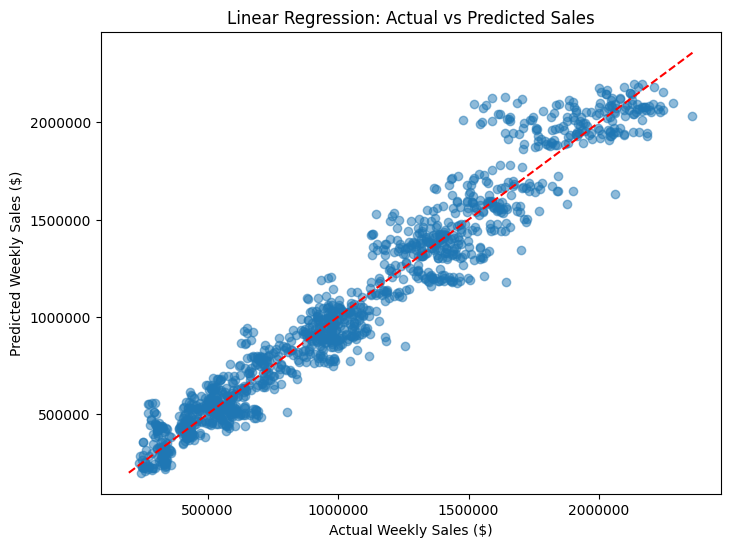

In [67]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    linear_predictions,
    alpha=0.5
)

minimum_value = min(
    y_test.min(),
    linear_predictions.min()
)

maximum_value = max(
    y_test.max(),
    linear_predictions.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    color="red",
    linestyle="--"
)

plt.title("Linear Regression: Actual vs Predicted Sales")
plt.xlabel("Actual Weekly Sales ($)")
plt.ylabel("Predicted Weekly Sales ($)")
plt.ticklabel_format(style="plain", axis="both")
plt.show()

**Actual-versus-predicted analysis:** Most predictions were reasonably close to the perfect-prediction line, supporting the strong R-squared result. However, the model tended to underpredict some of the highest sales observations. The visible clusters represent different stores with distinct normal sales levels.


In [68]:
linear_residuals = y_test - linear_predictions

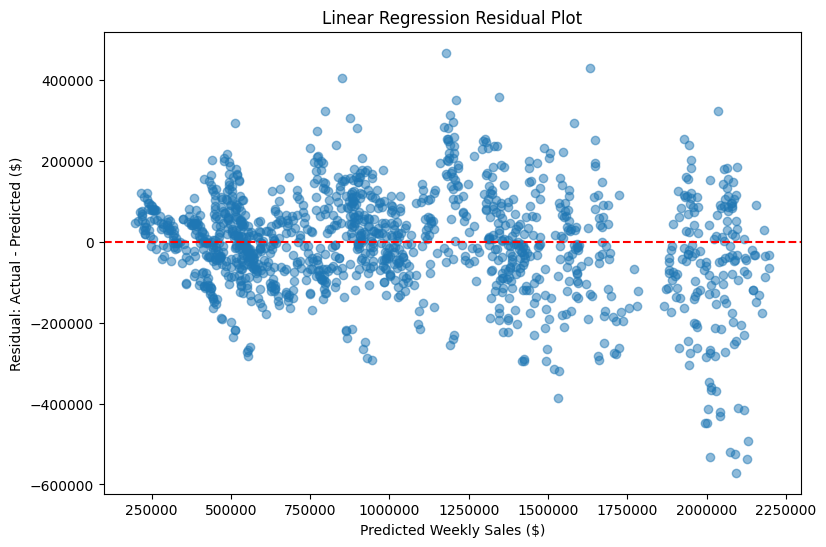

In [69]:
plt.figure(figsize=(9, 6))

plt.scatter(
    linear_predictions,
    linear_residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Linear Regression Residual Plot")
plt.xlabel("Predicted Weekly Sales ($)")
plt.ylabel("Residual: Actual - Predicted ($)")
plt.ticklabel_format(style="plain", axis="both")
plt.show()

**Residual analysis:** Residuals were distributed around zero, but they were not completely random. Error variation increased for higher predicted sales, and several clustered patterns were visible. This suggests heteroscedasticity and indicates that Linear Regression does not capture all nonlinear relationships and store-specific interactions.


## 6. Decision Tree Regressor

A Decision Tree predicts sales by repeatedly dividing observations using feature-based rules. Unlike Linear Regression, it can capture nonlinear relationships and interactions.


In [70]:
from sklearn.tree import DecisionTreeRegressor

In [71]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "store_encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numbers",
            "passthrough",
            numerical_features
        )
    ]
)

In [72]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessing", tree_preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                random_state=42
            )
        )
    ]
)

In [73]:
decision_tree_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('store_encoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Store']),
                                                 ('numbers', 'passthrough',
                                                  ['Holiday_Flag',
                                                   'Temperature', 'Fuel_Price',
                                                   'CPI', 'Unemployment',
                                                   'Year', 'Week_of_Year'])])),
                ('model', DecisionTreeRegressor(random_state=42))])

In [74]:
tree_train_predictions = decision_tree_model.predict(
    X_train
)

tree_test_predictions = decision_tree_model.predict(
    X_test
)

In [75]:
tree_train_mae = mean_absolute_error(
    y_train,
    tree_train_predictions
)

tree_test_mae = mean_absolute_error(
    y_test,
    tree_test_predictions
)

tree_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        tree_train_predictions
    )
)

tree_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tree_test_predictions
    )
)

tree_train_r2 = r2_score(
    y_train,
    tree_train_predictions
)

tree_test_r2 = r2_score(
    y_test,
    tree_test_predictions
)

In [76]:
print("Decision Tree Results")

print("Training MAE:", f"${tree_train_mae:,.2f}")
print("Testing MAE:", f"${tree_test_mae:,.2f}")

print("Training RMSE:", f"${tree_train_rmse:,.2f}")
print("Testing RMSE:", f"${tree_test_rmse:,.2f}")

print("Training R-squared:", round(tree_train_r2, 4))
print("Testing R-squared:", round(tree_test_r2, 4))

Decision Tree Results
Training MAE: $0.00
Testing MAE: $139,877.51
Training RMSE: $0.00
Testing RMSE: $197,368.95
Training R-squared: 1.0
Testing R-squared: 0.8632


**Unrestricted Decision Tree result:** The tree achieved zero training error and an R-squared score of 1.0, meaning it memorized the training data. Testing performance fell to an MAE of approximately $139,878 and an R-squared score of 0.8632. This large train-test gap demonstrates severe overfitting.


In [77]:
from sklearn.model_selection import (
    GridSearchCV,
    TimeSeriesSplit
)

In [78]:
sorted_train_indices = (
    df.loc[train_mask]
    .sort_values(["Date", "Store"])
    .index
)

X_train_sorted = X.loc[sorted_train_indices]
y_train_sorted = y.loc[sorted_train_indices]

In [79]:
time_series_cv = TimeSeriesSplit(
    n_splits=5
)

In [80]:
tree_parameters = {
    "model__max_depth": [
        3, 5, 8, 10, 15, None
    ],
    "model__min_samples_leaf": [
        1, 5, 10, 20
    ]
}

In [81]:
tree_search = GridSearchCV(
    estimator=decision_tree_model,
    param_grid=tree_parameters,
    scoring="neg_mean_absolute_error",
    cv=time_series_cv,
    n_jobs=-1
)

In [82]:
tree_search.fit(
    X_train_sorted,
    y_train_sorted
)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('store_encoder',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Store']),
                                                                        ('numbers',
                                                                         'passthrough',
                                                                         ['Holiday_Flag',
                                                                          'Temperature',
                                                                          'Fuel_Price',
                                                                          'CPI',
                                                                          'Unemployment',
                                                                          'Year',
                                                                          'Week_of_Year'])])),
                                       ('model',
                                        DecisionTreeRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [3, 5, 8, 10, 15, None],
                         'model__min_samples_leaf': [1, 5, 10, 20]},
             scoring='neg_mean_absolute_error')

In [83]:
print(
    "Best parameters:",
    tree_search.best_params_
)

print(
    "Best validation MAE:",
    f"${-tree_search.best_score_:,.2f}"
)

Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 10}
Best validation MAE: $112,161.07


In [84]:
best_tree_model = tree_search.best_estimator_

In [85]:
tuned_tree_train_predictions = (
    best_tree_model.predict(X_train)
)

tuned_tree_test_predictions = (
    best_tree_model.predict(X_test)
)

In [86]:
tuned_tree_train_mae = mean_absolute_error(
    y_train,
    tuned_tree_train_predictions
)

tuned_tree_test_mae = mean_absolute_error(
    y_test,
    tuned_tree_test_predictions
)

tuned_tree_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        tuned_tree_train_predictions
    )
)

tuned_tree_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_tree_test_predictions
    )
)

tuned_tree_train_r2 = r2_score(
    y_train,
    tuned_tree_train_predictions
)

tuned_tree_test_r2 = r2_score(
    y_test,
    tuned_tree_test_predictions
)

In [87]:
print("Tuned Decision Tree Results")

print(
    "Training MAE:",
    f"${tuned_tree_train_mae:,.2f}"
)
print(
    "Testing MAE:",
    f"${tuned_tree_test_mae:,.2f}"
)

print(
    "Training RMSE:",
    f"${tuned_tree_train_rmse:,.2f}"
)
print(
    "Testing RMSE:",
    f"${tuned_tree_test_rmse:,.2f}"
)

print(
    "Training R-squared:",
    round(tuned_tree_train_r2, 4)
)
print(
    "Testing R-squared:",
    round(tuned_tree_test_r2, 4)
)

Tuned Decision Tree Results
Training MAE: $58,988.38
Testing MAE: $72,798.02
Training RMSE: $113,458.62
Testing RMSE: $102,745.69
Training R-squared: 0.9606
Testing R-squared: 0.9629


**Tuned Decision Tree result:** Requiring at least 10 observations in each leaf substantially reduced overfitting. The tuned tree achieved a test MAE of approximately $72,798, an RMSE of $102,746, and an R-squared score of 0.9629. It outperformed Linear Regression and reduced test MAE by approximately 21.5%.


In [88]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Unrestricted Decision Tree",
        "Tuned Decision Tree"
    ],
    "Test_MAE": [
        linear_mae,
        tree_test_mae,
        tuned_tree_test_mae
    ],
    "Test_RMSE": [
        linear_rmse,
        tree_test_rmse,
        tuned_tree_test_rmse
    ],
    "Test_R2": [
        linear_r2,
        tree_test_r2,
        tuned_tree_test_r2
    ]
})

model_results

,Model,Test_MAE,Test_RMSE,Test_R2
0,Linear Regression,92751.493668,124413.393311,0.945634
1,Unrestricted Decision Tree,139877.506337,197368.950339,0.863179
2,Tuned Decision Tree,72798.021838,102745.688799,0.962921


In [89]:
model_results.style.format({
    "Test_MAE": "${:,.2f}",
    "Test_RMSE": "${:,.2f}",
    "Test_R2": "{:.4f}"
})

,Model,Test_MAE,Test_RMSE,Test_R2
0,Linear Regression,"$92,751.49","$124,413.39",0.9456
1,Unrestricted Decision Tree,"$139,877.51","$197,368.95",0.8632
2,Tuned Decision Tree,"$72,798.02","$102,745.69",0.9629


## 7. Random Forest Regressor

Random Forest combines predictions from multiple decision trees. Each tree uses a random sample of observations and features. Averaging the trees generally produces more stable predictions than a single decision tree.


In [90]:
from sklearn.ensemble import RandomForestRegressor

In [91]:
random_forest_model = Pipeline(steps=[
    ("preprocessing", tree_preprocessor),

    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

In [92]:
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('store_encoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Store']),
                                                 ('numbers', 'passthrough',
                                                  ['Holiday_Flag',
                                                   'Temperature', 'Fuel_Price',
                                                   'CPI', 'Unemployment',
                                                   'Year', 'Week_of_Year'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [93]:
rf_train_predictions = random_forest_model.predict(X_train)
rf_test_predictions = random_forest_model.predict(X_test)

In [94]:
rf_train_mae = mean_absolute_error(
    y_train,
    rf_train_predictions
)

rf_test_mae = mean_absolute_error(
    y_test,
    rf_test_predictions
)

rf_train_rmse = np.sqrt(
    mean_squared_error(y_train, rf_train_predictions)
)

rf_test_rmse = np.sqrt(
    mean_squared_error(y_test, rf_test_predictions)
)

rf_train_r2 = r2_score(
    y_train,
    rf_train_predictions
)

rf_test_r2 = r2_score(
    y_test,
    rf_test_predictions
)

In [95]:
print("Random Forest Results")

print("Training MAE:", f"${rf_train_mae:,.2f}")
print("Testing MAE:", f"${rf_test_mae:,.2f}")

print("Training RMSE:", f"${rf_train_rmse:,.2f}")
print("Testing RMSE:", f"${rf_test_rmse:,.2f}")

print("Training R-squared:", round(rf_train_r2, 4))
print("Testing R-squared:", round(rf_test_r2, 4))

Random Forest Results
Training MAE: $23,300.62
Testing MAE: $81,045.62
Training RMSE: $45,776.81
Testing RMSE: $121,156.93
Training R-squared: 0.9936
Testing R-squared: 0.9484


In [96]:
from sklearn.model_selection import RandomizedSearchCV

In [97]:
rf_tuning_pipeline = Pipeline(steps=[
    ("preprocessing", tree_preprocessor),

    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=1
    ))
])

In [98]:
rf_parameters = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 15, 20],
    "model__min_samples_leaf": [1, 5, 10, 20],
    "model__max_features": ["sqrt", 0.7, 1.0]
}

In [99]:
rf_search = RandomizedSearchCV(
    estimator=rf_tuning_pipeline,
    param_distributions=rf_parameters,
    n_iter=15,
    scoring="neg_mean_absolute_error",
    cv=time_series_cv,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train_sorted, y_train_sorted)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('store_encoder',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['Store']),
                                                                              ('numbers',
                                                                               'passthrough',
                                                                               ['Holiday_Flag',
                                                                                'Temperature',
                                                                                'Fuel_Price',
                                                                                'CPI',
                                                                                'Unemployment',
                                                                                'Year',
                                                                                'Week_of_Year'])])),
                                             ('model',
                                              RandomForestRegressor(n_jobs=1,
                                                                    random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 10, 15, 20],
                                        'model__max_features': ['sqrt', 0.7,
                                                                1.0],
                                        'model__min_samples_leaf': [1, 5, 10,
                                                                    20],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='neg_mean_absolute_error')

In [100]:
print("Best parameters:", rf_search.best_params_)

print(
    "Best validation MAE:",
    f"${-rf_search.best_score_:,.2f}"
)

Best parameters: {'model__n_estimators': 100, 'model__min_samples_leaf': 1, 'model__max_features': 0.7, 'model__max_depth': None}
Best validation MAE: $99,845.38


In [101]:
tuned_rf_model = rf_search.best_estimator_

tuned_rf_train_predictions = tuned_rf_model.predict(
    X_train_sorted
)

tuned_rf_test_predictions = tuned_rf_model.predict(
    X_test
)

In [102]:
tuned_rf_train_mae = mean_absolute_error(
    y_train_sorted,
    tuned_rf_train_predictions
)

tuned_rf_test_mae = mean_absolute_error(
    y_test,
    tuned_rf_test_predictions
)

tuned_rf_train_rmse = np.sqrt(
    mean_squared_error(
        y_train_sorted,
        tuned_rf_train_predictions
    )
)

tuned_rf_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_rf_test_predictions
    )
)

tuned_rf_train_r2 = r2_score(
    y_train_sorted,
    tuned_rf_train_predictions
)

tuned_rf_test_r2 = r2_score(
    y_test,
    tuned_rf_test_predictions
)


In [103]:
print("Tuned Random Forest Results")

print("Training MAE:", f"${tuned_rf_train_mae:,.2f}")
print("Testing MAE:", f"${tuned_rf_test_mae:,.2f}")

print("Training RMSE:", f"${tuned_rf_train_rmse:,.2f}")
print("Testing RMSE:", f"${tuned_rf_test_rmse:,.2f}")

print(
    "Training R-squared:",
    round(tuned_rf_train_r2, 4)
)

print(
    "Testing R-squared:",
    round(tuned_rf_test_r2, 4)
)


Tuned Random Forest Results
Training MAE: $23,960.87
Testing MAE: $79,513.17
Training RMSE: $48,046.12
Testing RMSE: $114,721.48
Training R-squared: 0.9929
Testing R-squared: 0.9538


## 8. Gradient Boosting Regressor

Gradient Boosting builds decision trees sequentially. Each new tree focuses on correcting the errors made by the existing collection of trees.


In [104]:
from sklearn.ensemble import GradientBoostingRegressor

In [105]:
gradient_preprocessor = ColumnTransformer(
    transformers=[
        (
            "store_encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numbers",
            "passthrough",
            numerical_features
        )
    ]
)

In [106]:
gradient_boosting_model = Pipeline(steps=[
    ("preprocessing", gradient_preprocessor),

    ("model", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

In [107]:
gradient_boosting_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('store_encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Store']),
                                                 ('numbers', 'passthrough',
                                                  ['Holiday_Flag',
                                                   'Temperature', 'Fuel_Price',
                                                   'CPI', 'Unemployment',
                                                   'Year', 'Week_of_Year'])])),
                ('model', GradientBoostingRegressor(random_state=42))])

In [108]:
gb_train_predictions = gradient_boosting_model.predict(
    X_train
)

gb_test_predictions = gradient_boosting_model.predict(
    X_test
)

In [109]:
gb_train_mae = mean_absolute_error(
    y_train,
    gb_train_predictions
)

gb_test_mae = mean_absolute_error(
    y_test,
    gb_test_predictions
)

gb_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        gb_train_predictions
    )
)

gb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_test_predictions
    )
)

gb_train_r2 = r2_score(
    y_train,
    gb_train_predictions
)

gb_test_r2 = r2_score(
    y_test,
    gb_test_predictions
)

In [110]:
print("Gradient Boosting Results")

print("Training MAE:", f"${gb_train_mae:,.2f}")
print("Testing MAE:", f"${gb_test_mae:,.2f}")

print("Training RMSE:", f"${gb_train_rmse:,.2f}")
print("Testing RMSE:", f"${gb_test_rmse:,.2f}")

print(
    "Training R-squared:",
    round(gb_train_r2, 4)
)

print(
    "Testing R-squared:",
    round(gb_test_r2, 4)
)

Gradient Boosting Results
Training MAE: $181,721.42
Testing MAE: $176,067.72
Training RMSE: $216,178.72
Testing RMSE: $200,697.80
Training R-squared: 0.8571
Testing R-squared: 0.8585


In [111]:
gb_tuning_pipeline = Pipeline(steps=[
    ("preprocessing", gradient_preprocessor),

    ("model", GradientBoostingRegressor(
        random_state=42
    ))
])

In [112]:
gb_parameters = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_leaf": [1, 5, 10, 20],
    "model__subsample": [0.7, 0.85, 1.0]
}

In [ ]:
gb_search = RandomizedSearchCV(
    estimator=gb_tuning_pipeline,
    param_distributions=gb_parameters,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=time_series_cv,
    random_state=42,
    n_jobs=-1
)

gb_search.fit(
    X_train_sorted,
    y_train_sorted
)

In [ ]:
print(
    "Best parameters:",
    gb_search.best_params_
)

print(
    "Best validation MAE:",
    f"${-gb_search.best_score_:,.2f}"
)

In [ ]:
tuned_gb_model = gb_search.best_estimator_

tuned_gb_train_predictions = tuned_gb_model.predict(
    X_train_sorted
)

tuned_gb_test_predictions = tuned_gb_model.predict(
    X_test
)

In [ ]:
tuned_gb_train_mae = mean_absolute_error(
    y_train_sorted,
    tuned_gb_train_predictions
)

tuned_gb_test_mae = mean_absolute_error(
    y_test,
    tuned_gb_test_predictions
)

tuned_gb_train_rmse = np.sqrt(
    mean_squared_error(
        y_train_sorted,
        tuned_gb_train_predictions
    )
)

tuned_gb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_gb_test_predictions
    )
)

tuned_gb_train_r2 = r2_score(
    y_train_sorted,
    tuned_gb_train_predictions
)

tuned_gb_test_r2 = r2_score(
    y_test,
    tuned_gb_test_predictions
)

In [ ]:
print("Tuned Gradient Boosting Results")

print("Training MAE:", f"${tuned_gb_train_mae:,.2f}")
print("Testing MAE:", f"${tuned_gb_test_mae:,.2f}")

print("Training RMSE:", f"${tuned_gb_train_rmse:,.2f}")
print("Testing RMSE:", f"${tuned_gb_test_rmse:,.2f}")

print(
    "Training R-squared:",
    round(tuned_gb_train_r2, 4)
)

print(
    "Testing R-squared:",
    round(tuned_gb_test_r2, 4)
)

In [ ]:
final_model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Tuned Decision Tree",
        "Tuned Random Forest",
        "Tuned Gradient Boosting"
    ],

    "Training MAE": [
        linear_train_mae,
        tuned_tree_train_mae,
        tuned_rf_train_mae,
        tuned_gb_train_mae
    ],

    "Testing MAE": [
        linear_mae,
        tuned_tree_test_mae,
        tuned_rf_test_mae,
        tuned_gb_test_mae
    ],

    "Testing RMSE": [
        linear_rmse,
        tuned_tree_test_rmse,
        tuned_rf_test_rmse,
        tuned_gb_test_rmse
    ],

    "Testing R-squared": [
        linear_r2,
        tuned_tree_test_r2,
        tuned_rf_test_r2,
        tuned_gb_test_r2
    ]
})

final_model_results = final_model_results.sort_values(
    by="Testing MAE"
).reset_index(drop=True)

final_model_results.round(2)

## 9. Model Comparison and Recommendation

The **tuned Decision Tree** produced the best predictions on the future holdout period:

- **MAE:** $72,798
- **RMSE:** $102,746
- **R²:** 0.9629

Compared with Linear Regression, the selected model reduced MAE by approximately **21.5%** and RMSE by approximately **17.4%**. Tuning also corrected the severe overfitting observed in the unrestricted tree.

Random Forest and Gradient Boosting performed strongly, but their lower training errors did not translate into better future-period results. This demonstrates why the final model should be selected using unseen data rather than training performance.

### Business interpretation

An MAE of about $72,800 means that a typical store-week prediction differs from actual sales by roughly that amount. Forecasts could support inventory, staffing, budgeting, and promotion planning, but they should be combined with operational judgment—especially near major holidays.

### Limitations and next steps

- The dataset ends in October 2012, so the holdout period does not contain Thanksgiving or Christmas peaks.
- Promotions, markdowns, store size, departments, and local events are unavailable.
- Lagged sales and rolling averages could improve predictive performance.
- Future work should use rolling-origin backtesting across multiple forecast windows and compare dedicated time-series models.

### Final takeaway

The project shows that disciplined validation matters as much as model complexity. A tuned, interpretable Decision Tree generalized better than more complex ensemble models on this dataset.
